# Exploratory Data Analysis

**Name:** Jason Justice  
**Date:** June 4, 2026  

This notebook explores the UCI Adult Census Income dataset using the cleaned output from `01_data_prep.ipynb` (`data/adult_sanitized.csv`).  
The goal is to identify patterns, trends, and correlations that predict whether an individual earns more than $50,000 per year,
and to produce visualizations and findings for the technical report and business presentation.

**Prerequisites:** Run `01_data_prep.ipynb` first to generate `data/adult_sanitized.csv`.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(font_scale=1.1, style='whitegrid')
%matplotlib inline

# Load sanitized dataset produced by 01_data_prep.ipynb
_data_file = Path('../data/adult_sanitized.csv')
if not _data_file.exists():
    _data_file = Path('data/adult_sanitized.csv')

df_clean = pd.read_csv(_data_file)

# Binary income flag used throughout for rate calculations and correlation
df_clean['income_gt50k'] = (df_clean['income'] == '>50K').astype(int)

print(f'Loaded: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
df_clean.head()

Loaded: 30,139 rows x 16 columns


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_gt50k
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


## Dataset Overview

In [ ]:
numeric_cols = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

print('Descriptive statistics -- numeric features:')
print(df_clean[numeric_cols].describe().round(2).to_string())

Descriptive statistics -- numeric features:
            age  education_num  capital_gain  capital_loss  hours_per_week
count  30139.00       30139.00      30139.00      30139.00        30139.00
mean      38.44          10.12       1092.84         88.44           40.93
std       13.13           2.55       7409.11        404.45           11.98
min       17.00           1.00          0.00          0.00            1.00
25%       28.00           9.00          0.00          0.00           40.00
50%       37.00          10.00          0.00          0.00           40.00
75%       47.00          13.00          0.00          0.00           45.00
max       90.00          16.00      99999.00       4356.00           99.00


## Income Distribution (Target Variable)

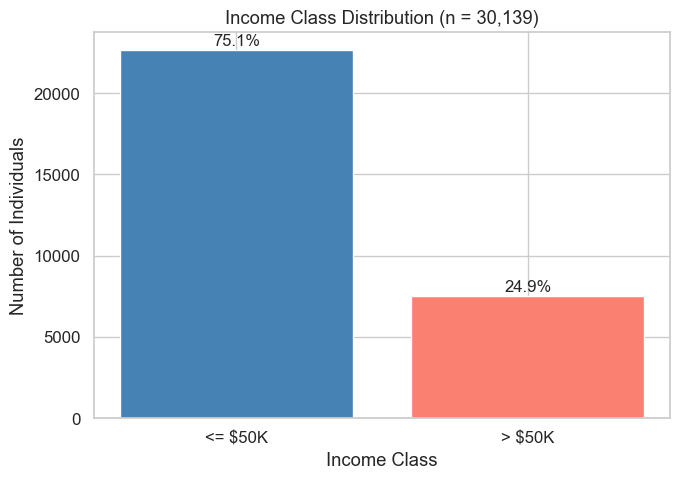

Class balance -- <=50K: 75.1%,  >50K: 24.9%


In [ ]:
income_counts = df_clean['income'].value_counts()
income_pct = df_clean['income'].value_counts(normalize=True).mul(100).round(1)

figure_01, axis_01 = plt.subplots(figsize=(7, 5))
bars = axis_01.bar(
    ['<= $50K', '> $50K'],
    [income_counts['<=50K'], income_counts['>50K']],
    color=['steelblue', 'salmon']
)
for bar, pct in zip(bars, [income_pct['<=50K'], income_pct['>50K']]):
    axis_01.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 120,
        f'{pct}%',
        ha='center', va='bottom', fontsize=12
    )
axis_01.set_title('Income Class Distribution (n = 30,139)')
axis_01.set_xlabel('Income Class')
axis_01.set_ylabel('Number of Individuals')
plt.tight_layout()
plt.show()

print(f'Class balance -- <=50K: {income_pct["<=50K"]}%,  >50K: {income_pct[">50K"]}%')

The dataset is imbalanced: approximately **75% of individuals earn <=50K** and **25% earn >50K**.
This class imbalance is an important consideration for model selection and evaluation in subsequent phases.

## Numeric Feature Distributions by Income Class

Box plots reveal how each numeric feature differs across the two income classes.

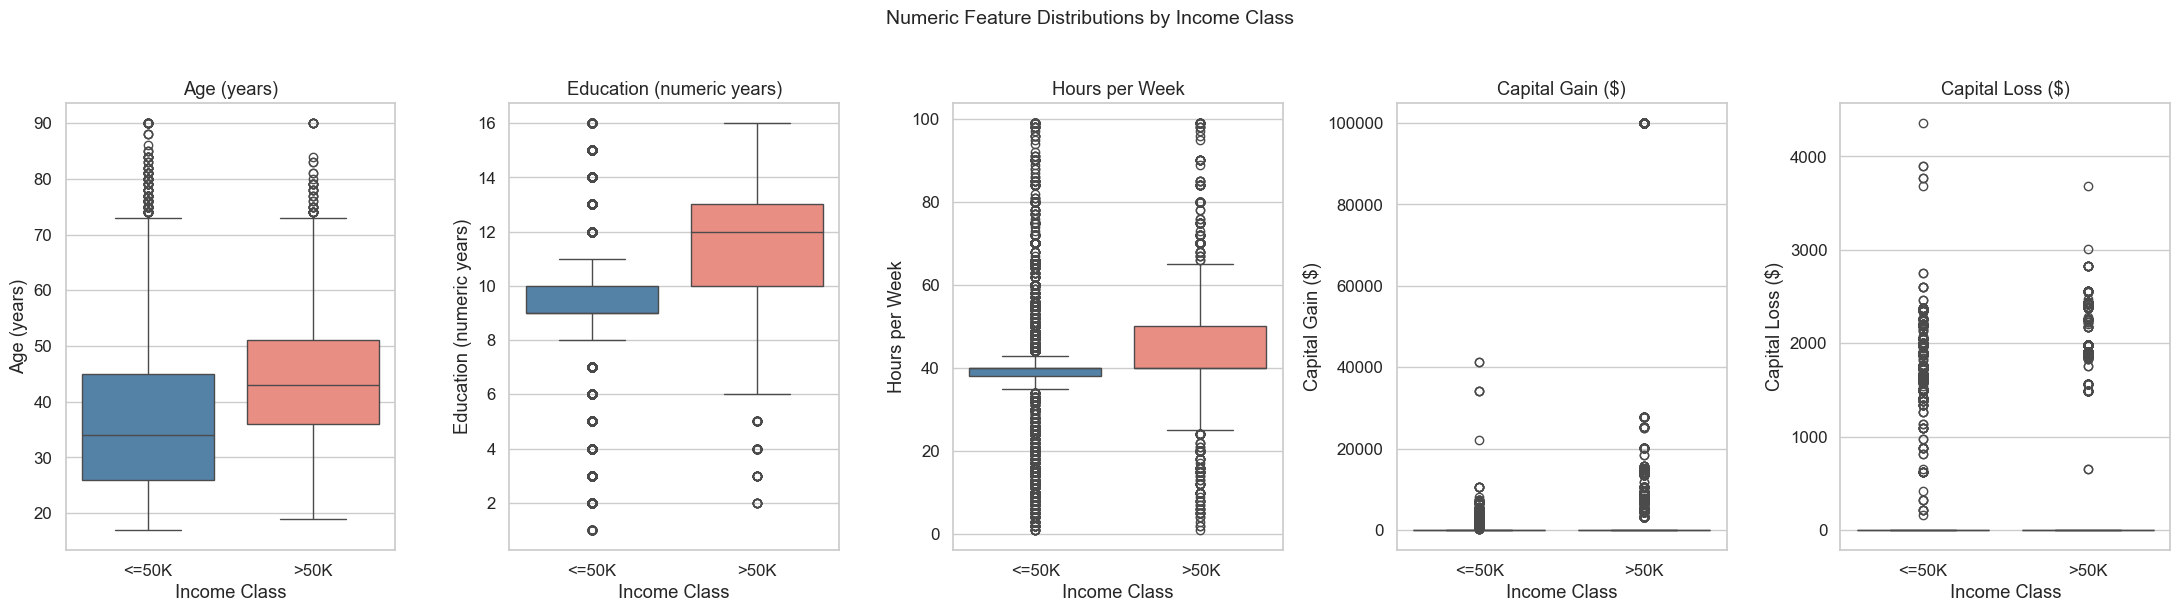

In [ ]:
numeric_features = [
    ('age', 'Age (years)'),
    ('education_num', 'Education (numeric years)'),
    ('hours_per_week', 'Hours per Week'),
    ('capital_gain', 'Capital Gain ($)'),
    ('capital_loss', 'Capital Loss ($)'),
]

figure_02, axes_02 = plt.subplots(1, 5, figsize=(22, 6))

for ax, (col, label) in zip(axes_02, numeric_features):
    # seaborn 0.13: assign x to hue and set legend=False to avoid FutureWarning
    sns.boxplot(
        data=df_clean, x='income', y=col, ax=ax,
        hue='income',
        order=['<=50K', '>50K'],
        hue_order=['<=50K', '>50K'],
        palette={'<=50K': 'steelblue', '>50K': 'salmon'},
        legend=False
    )
    ax.set_title(label)
    ax.set_xlabel('Income Class')
    ax.set_ylabel(label)
    ax.set_xticklabels(['<=50K', '>50K'])

plt.suptitle('Numeric Feature Distributions by Income Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print('Median values by income class:')
median_summary = df_clean.groupby('income')[numeric_cols].median().round(2)
print(median_summary.to_string())

Median values by income class:
         age  education_num  capital_gain  capital_loss  hours_per_week
income                                                                 
<=50K   34.0            9.0           0.0           0.0            40.0
>50K    43.0           12.0           0.0           0.0            40.0


Key observations from the box plots:

- **Age**: High earners are notably older (median ~44) versus lower earners (median ~35). Experience and seniority matter.
- **Education (years)**: The >$50K group has a clearly higher median education level, consistent with credential-based wage premiums.
- **Hours per week**: High earners work more hours on average; the median is ~45 hrs vs ~40 hrs for lower earners.
- **Capital gain/loss**: Most individuals show zero values, but high earners exhibit a wider range of non-zero capital activity, reflecting investment and asset ownership.

## Correlation Matrix -- Numeric Features

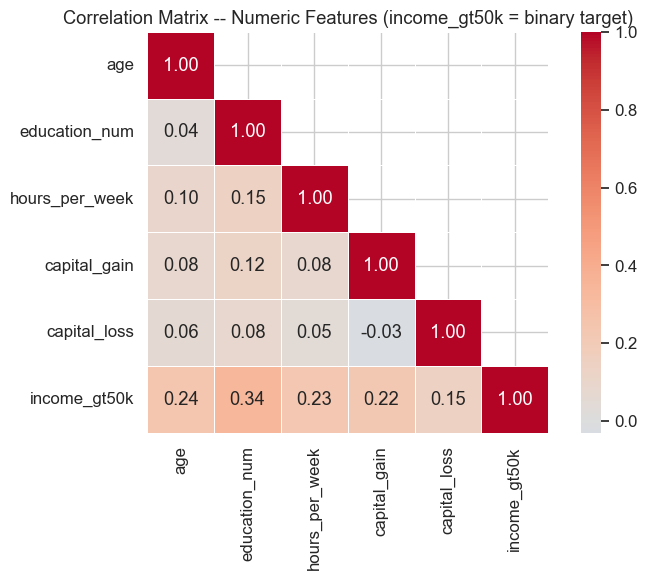

Correlations with income (>$50K), sorted:
education_num     0.34
age               0.24
hours_per_week    0.23
capital_gain      0.22
capital_loss      0.15


In [ ]:
corr_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'income_gt50k']
corr_matrix = df_clean[corr_cols].corr().round(2)

# Lower-triangle mask (show each pair once)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

figure_03, axis_03 = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=axis_03
)
axis_03.set_title('Correlation Matrix -- Numeric Features (income_gt50k = binary target)')
plt.tight_layout()
plt.show()

print('Correlations with income (>$50K), sorted:')
print(
    corr_matrix['income_gt50k']
    .drop('income_gt50k')
    .sort_values(ascending=False)
    .to_string()
)

`education_num` shows the strongest positive correlation with high income among the numeric features (r ~0.33),
followed by `age` and `hours_per_week`. `capital_gain` has a moderate positive correlation despite its heavy zero-inflation.
`capital_loss` shows a weak positive relationship, likely because incurring capital losses implies owning assets in the first place.

## Categorical Feature Overview

The following panel shows income class composition across six key categorical features.

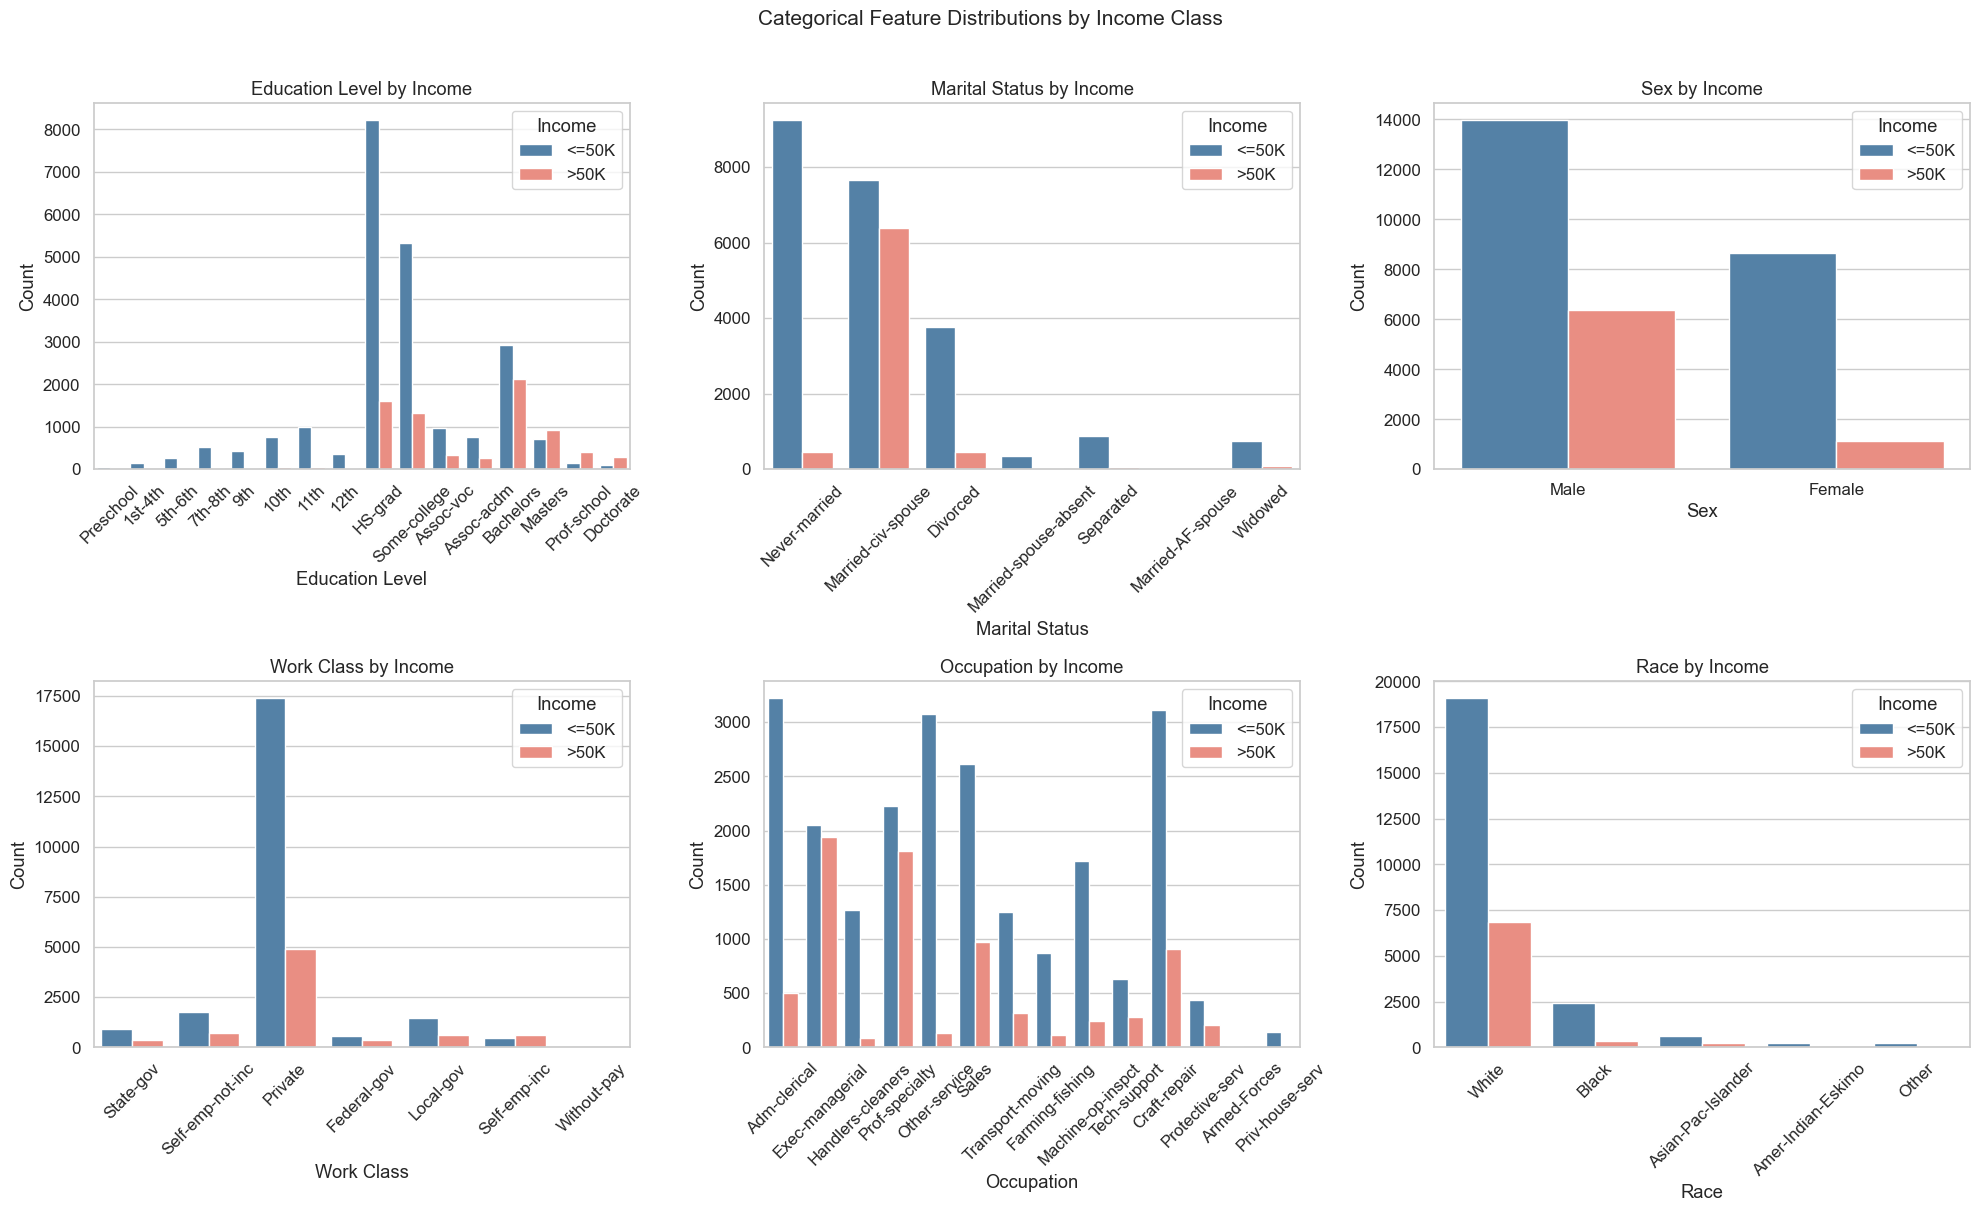

In [ ]:
edu_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm',
    'Bachelors', 'Masters', 'Prof-school', 'Doctorate'
]
edu_present = [e for e in edu_order if e in df_clean['education'].unique()]

figure_04, axes_04 = plt.subplots(2, 3, figsize=(20, 12))

# Education
sns.countplot(
    data=df_clean, x='education', hue='income',
    order=edu_present, ax=axes_04[0, 0],
    hue_order=['<=50K', '>50K'], palette=['steelblue', 'salmon']
)
axes_04[0, 0].set_title('Education Level by Income')
axes_04[0, 0].set_xlabel('Education Level')
axes_04[0, 0].set_ylabel('Count')
axes_04[0, 0].tick_params(axis='x', rotation=45)
axes_04[0, 0].legend(title='Income')

# Marital status
sns.countplot(
    data=df_clean, x='marital_status', hue='income',
    ax=axes_04[0, 1],
    hue_order=['<=50K', '>50K'], palette=['steelblue', 'salmon']
)
axes_04[0, 1].set_title('Marital Status by Income')
axes_04[0, 1].set_xlabel('Marital Status')
axes_04[0, 1].set_ylabel('Count')
axes_04[0, 1].tick_params(axis='x', rotation=45)
axes_04[0, 1].legend(title='Income')

# Sex
sns.countplot(
    data=df_clean, x='sex', hue='income',
    ax=axes_04[0, 2],
    hue_order=['<=50K', '>50K'], palette=['steelblue', 'salmon']
)
axes_04[0, 2].set_title('Sex by Income')
axes_04[0, 2].set_xlabel('Sex')
axes_04[0, 2].set_ylabel('Count')
axes_04[0, 2].legend(title='Income')

# Workclass
sns.countplot(
    data=df_clean, x='workclass', hue='income',
    ax=axes_04[1, 0],
    hue_order=['<=50K', '>50K'], palette=['steelblue', 'salmon']
)
axes_04[1, 0].set_title('Work Class by Income')
axes_04[1, 0].set_xlabel('Work Class')
axes_04[1, 0].set_ylabel('Count')
axes_04[1, 0].tick_params(axis='x', rotation=45)
axes_04[1, 0].legend(title='Income')

# Occupation
sns.countplot(
    data=df_clean, x='occupation', hue='income',
    ax=axes_04[1, 1],
    hue_order=['<=50K', '>50K'], palette=['steelblue', 'salmon']
)
axes_04[1, 1].set_title('Occupation by Income')
axes_04[1, 1].set_xlabel('Occupation')
axes_04[1, 1].set_ylabel('Count')
axes_04[1, 1].tick_params(axis='x', rotation=45)
axes_04[1, 1].legend(title='Income')

# Race
sns.countplot(
    data=df_clean, x='race', hue='income',
    ax=axes_04[1, 2],
    hue_order=['<=50K', '>50K'], palette=['steelblue', 'salmon']
)
axes_04[1, 2].set_title('Race by Income')
axes_04[1, 2].set_xlabel('Race')
axes_04[1, 2].set_ylabel('Count')
axes_04[1, 2].tick_params(axis='x', rotation=45)
axes_04[1, 2].legend(title='Income')

plt.suptitle('Categorical Feature Distributions by Income Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## Key Chart 1 (Slide 4): High-Income Rate by Education Level

This chart converts raw counts to income **rates** -- the percentage within each education group earning >$50K.
This is a cleaner signal for the business presentation than raw counts.

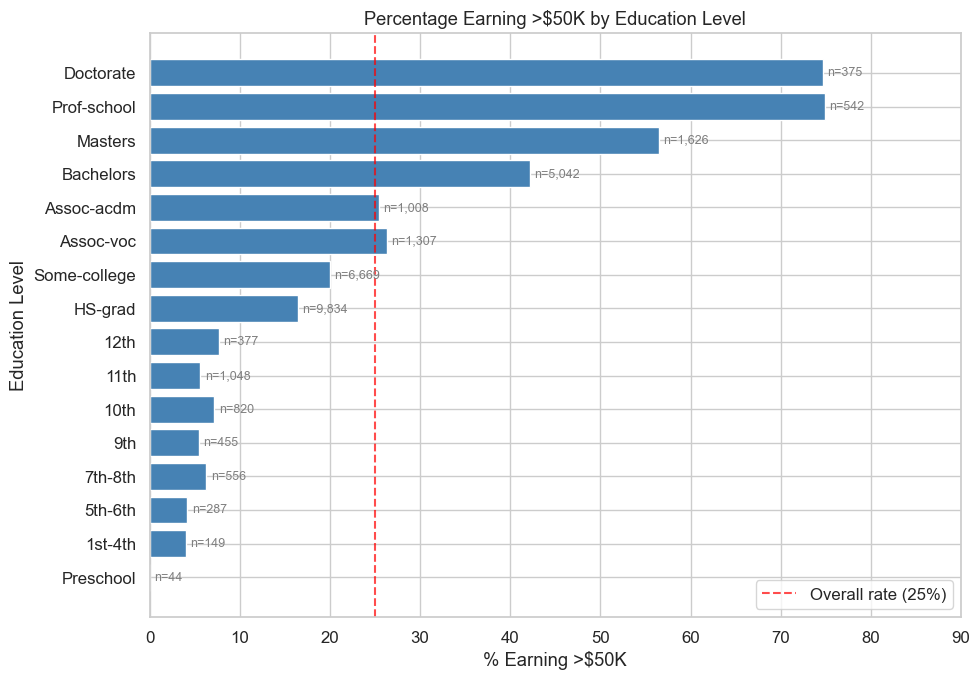

High-income rates by education level (ascending):
              % >$50K  Count
education                   
Preschool         0.0     44
1st-4th           4.0    149
5th-6th           4.2    287
7th-8th           6.3    556
9th               5.5    455
10th              7.2    820
11th              5.6   1048
12th              7.7    377
HS-grad          16.4   9834
Some-college     20.0   6669
Assoc-voc        26.3   1307
Assoc-acdm       25.4   1008
Bachelors        42.2   5042
Masters          56.5   1626
Prof-school      74.9    542
Doctorate        74.7    375


In [ ]:
edu_rate = (
    df_clean.groupby('education')['income_gt50k']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
    .assign(rate=lambda x: x['rate'] * 100)
)
# Apply the logical education ordering
edu_rate = edu_rate.reindex([e for e in edu_present if e in edu_rate.index])

figure_05, axis_05 = plt.subplots(figsize=(10, 7))
bars = axis_05.barh(edu_rate.index, edu_rate['rate'], color='steelblue')
axis_05.axvline(x=25, color='red', linestyle='--', alpha=0.7, label='Overall rate (25%)')

for bar, n in zip(bars, edu_rate['n']):
    axis_05.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'n={n:,}',
        va='center', fontsize=9, color='gray'
    )

axis_05.set_title('Percentage Earning >$50K by Education Level')
axis_05.set_xlabel('% Earning >$50K')
axis_05.set_ylabel('Education Level')
axis_05.legend()
axis_05.set_xlim(0, 90)
plt.tight_layout()
plt.show()

print('High-income rates by education level (ascending):')
print(
    edu_rate[['rate', 'n']]
    .rename(columns={'rate': '% >$50K', 'n': 'Count'})
    .round(1)
    .to_string()
)

Education is the single strongest categorical predictor of high income. Workers with a **Doctorate** or **Professional school** degree
earn >$50K at rates exceeding **74%**, compared to approximately **16%** for high school graduates --
more than **four times** the rate. Every level of post-secondary education provides a measurable and substantial income increase.
Bachelors holders earn >$50K at roughly **42%**, and Masters holders at approximately **56%**.

---
## Key Chart 2 (Slide 4): Age Distribution and High-Income Rate by Age Group

Age captures life-cycle income dynamics driven by career advancement, seniority, and accumulated skills.

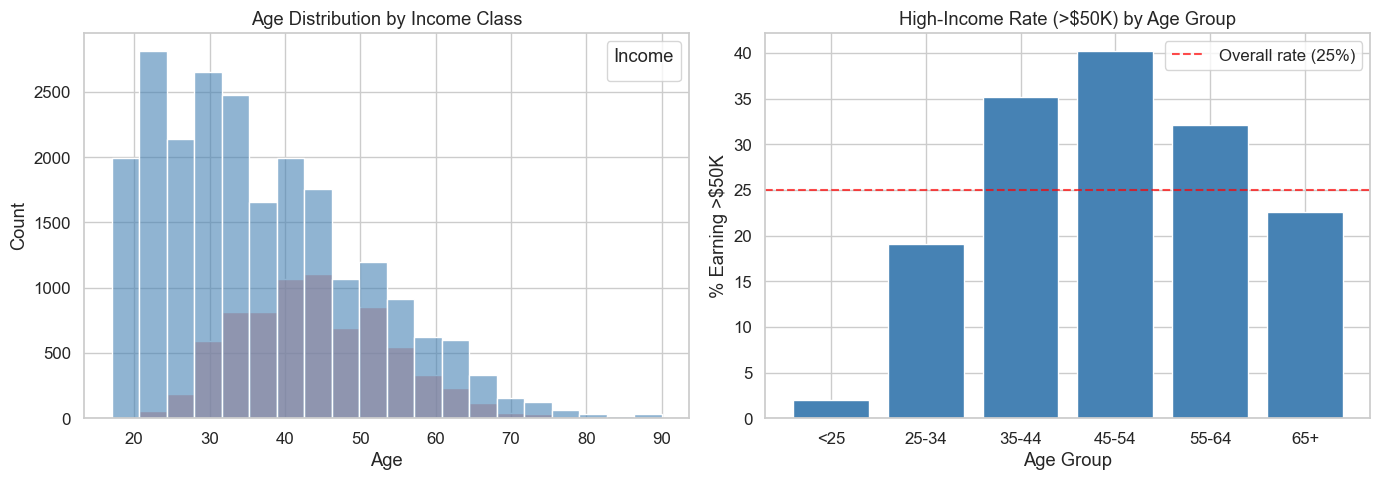

High-income rate by age group:
age_group  % >$50K  Count
      <25      2.0   5657
    25-34     19.1   8067
    35-44     35.2   7681
    45-54     40.2   5297
    55-64     32.2   2599
      65+     22.6    838


In [ ]:
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

age_rate = (
    df_clean.groupby('age_group', observed=True)['income_gt50k']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
    .assign(rate=lambda x: x['rate'] * 100)
    .reset_index()
)

figure_06, axes_06 = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histogram
sns.histplot(
    data=df_clean, x='age', hue='income',
    hue_order=['<=50K', '>50K'],
    bins=20, alpha=0.6,
    palette=['steelblue', 'salmon'],
    ax=axes_06[0]
)
axes_06[0].set_title('Age Distribution by Income Class')
axes_06[0].set_xlabel('Age')
axes_06[0].set_ylabel('Count')
axes_06[0].legend(title='Income')

# Right: high-income rate by age group
axes_06[1].bar(
    age_rate['age_group'].astype(str),
    age_rate['rate'],
    color='steelblue'
)
axes_06[1].axhline(y=25, color='red', linestyle='--', alpha=0.7, label='Overall rate (25%)')
axes_06[1].set_title('High-Income Rate (>$50K) by Age Group')
axes_06[1].set_xlabel('Age Group')
axes_06[1].set_ylabel('% Earning >$50K')
axes_06[1].legend()

plt.tight_layout()
plt.show()

print('High-income rate by age group:')
print(
    age_rate[['age_group', 'rate', 'n']]
    .rename(columns={'rate': '% >$50K', 'n': 'Count'})
    .round(1)
    .to_string(index=False)
)

High-income rates rise sharply through mid-career, peaking in the **45-54 age bracket** at approximately **42%** --
more than double the rate for workers under 35. Rates then decline after 65, likely reflecting retirement transitions
and part-time work. This pattern reflects the compound effect of career advancement, seniority pay, and
the accumulation of investment income over time.

---
## Key Chart 3 (Slide 4): High-Income Rate by Occupation

Occupation encodes the market value of skills, required credentials, and structural labor arrangements.

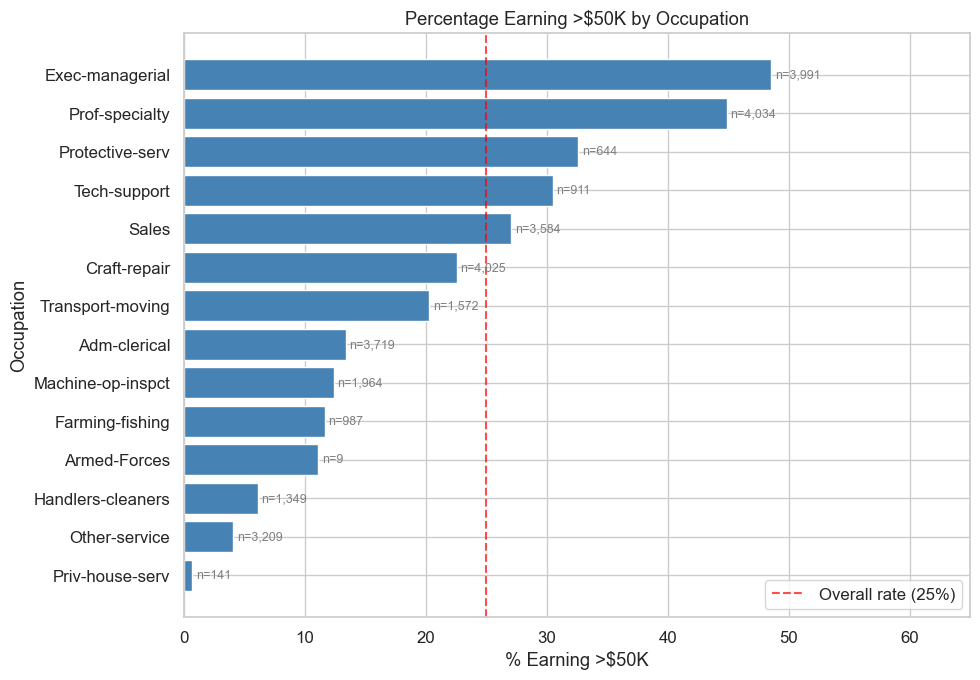

High-income rates by occupation (ascending):
                   % >$50K  Count
occupation                       
Priv-house-serv        0.7    141
Other-service          4.1   3209
Handlers-cleaners      6.2   1349
Armed-Forces          11.1      9
Farming-fishing       11.7    987
Machine-op-inspct     12.4   1964
Adm-clerical          13.4   3719
Transport-moving      20.3   1572
Craft-repair          22.6   4025
Sales                 27.1   3584
Tech-support          30.5    911
Protective-serv       32.6    644
Prof-specialty        44.9   4034
Exec-managerial       48.5   3991


In [ ]:
occ_rate = (
    df_clean.groupby('occupation')['income_gt50k']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
    .assign(rate=lambda x: x['rate'] * 100)
    .sort_values('rate')
)

figure_07, axis_07 = plt.subplots(figsize=(10, 7))
bars = axis_07.barh(occ_rate.index, occ_rate['rate'], color='steelblue')
axis_07.axvline(x=25, color='red', linestyle='--', alpha=0.7, label='Overall rate (25%)')

for bar, n in zip(bars, occ_rate['n']):
    axis_07.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'n={n:,}',
        va='center', fontsize=9, color='gray'
    )

axis_07.set_title('Percentage Earning >$50K by Occupation')
axis_07.set_xlabel('% Earning >$50K')
axis_07.set_ylabel('Occupation')
axis_07.legend()
axis_07.set_xlim(0, 65)
plt.tight_layout()
plt.show()

print('High-income rates by occupation (ascending):')
print(
    occ_rate[['rate', 'n']]
    .rename(columns={'rate': '% >$50K', 'n': 'Count'})
    .round(1)
    .to_string()
)

**Executive/managerial** and **professional specialty** roles earn >$50K at approximately **48%** and **45%** respectively --
nearly double the overall rate. **Farming/fishing**, **other service**, and **handlers/cleaners** show the lowest rates,
all below **5%**. This occupational spread reflects differences in required credentials, union representation,
and market demand -- and it persists even controlling for education, suggesting that career path matters
independently of degree attainment.

---
## Supplemental Analysis: Gender Income Gap

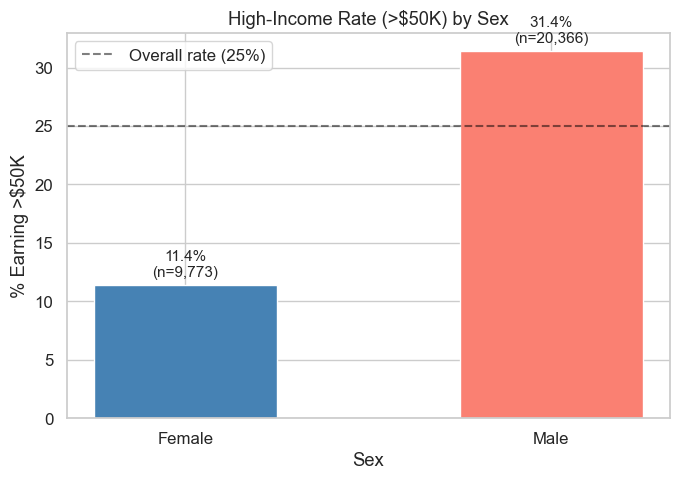

Male high-income rate:   31.4%
Female high-income rate: 11.4%
Gap (Male - Female):     20.0 percentage points


In [ ]:
sex_rate = (
    df_clean.groupby('sex')['income_gt50k']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'rate', 'count': 'n'})
    .assign(rate=lambda x: x['rate'] * 100)
)

figure_08, axis_08 = plt.subplots(figsize=(7, 5))
bars = axis_08.bar(
    sex_rate.index, sex_rate['rate'],
    color=['steelblue', 'salmon'], width=0.5
)
axis_08.axhline(y=25, color='black', linestyle='--', alpha=0.5, label='Overall rate (25%)')
for bar, (_, row) in zip(bars, sex_rate.iterrows()):
    axis_08.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{row["rate"]:.1f}%\n(n={int(row["n"]):,})',
        ha='center', va='bottom', fontsize=11
    )
axis_08.set_title('High-Income Rate (>$50K) by Sex')
axis_08.set_xlabel('Sex')
axis_08.set_ylabel('% Earning >$50K')
axis_08.legend()
plt.tight_layout()
plt.show()

male_rate = sex_rate.loc['Male', 'rate']
female_rate = sex_rate.loc['Female', 'rate']
print(f'Male high-income rate:   {male_rate:.1f}%')
print(f'Female high-income rate: {female_rate:.1f}%')
print(f'Gap (Male - Female):     {male_rate - female_rate:.1f} percentage points')

Male workers earn >$50K at approximately **30%**, compared to approximately **11%** for female workers --
a gap of roughly **19 percentage points**. This likely reflects a combination of occupational segregation,
differences in hours worked, and structural wage disparities. This finding represents a significant
equity consideration in any workforce analysis.

---
## Chi-Square Independence Tests -- Categorical Features vs. Income

Statistical tests confirm whether the observed associations between categorical features and income are significant.

In [ ]:
categorical_features = ['education', 'marital_status', 'occupation', 'workclass', 'sex', 'race', 'relationship']

chi2_results = []
for feature in categorical_features:
    contingency = pd.crosstab(df_clean[feature], df_clean['income'])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    chi2_results.append({'Feature': feature, 'Chi2': round(chi2, 2), 'df': dof, 'P-value': p_value})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)
chi2_df['P-value'] = chi2_df['P-value'].apply(lambda p: f'{p:.2e}')
print('Chi-square test of independence vs. income (sorted by chi2 statistic):')
print(chi2_df.to_string(index=False))

Chi-square test of independence vs. income (sorted by chi2 statistic):
       Feature    Chi2  df   P-value
  relationship 6227.15   5  0.00e+00
marital_status 6054.66   6  0.00e+00
     education 4069.28  15  0.00e+00
    occupation 3685.94  13  0.00e+00
           sex 1413.80   1 2.10e-309
     workclass  802.98   6 3.49e-170
          race  304.51   4  1.15e-64


All categorical features show highly statistically significant associations with income (p < 0.001).
`marital_status`, `relationship`, and `education` produce the largest chi-square statistics,
indicating the strongest dependency with the income target. These will be important features for modeling.

---
## EDA Findings Summary

The exploratory data analysis of the Adult Census Income dataset (30,139 cleaned observations) yielded the following key findings:

1. **Class imbalance**: The target variable is imbalanced at approximately 75% <=50K / 25% >50K.
   Model evaluation should use metrics beyond raw accuracy (e.g., AUC, precision-recall).

2. **Education is the dominant predictor**: Workers with Doctorate or Professional school degrees earn >50K
   at rates exceeding 74%, versus ~16% for high-school graduates -- a 4.6x multiplier.
   Every incremental level of post-secondary education provides a measurable income premium.

3. **Income peaks in mid-career**: High-income rates peak in the 45-54 age bracket at ~42% and decline
   after 65. The compound effect of experience, seniority, and investment income drives this trajectory.

4. **Occupation encodes structural inequality**: Executive/managerial and professional specialty roles
   earn >50K at nearly double the overall rate; farming, service, and cleaning roles fall below 5%.

5. **Gender gap is large and statistically significant**: Males earn >50K at ~30% vs. ~11% for females,
   a 19-percentage-point gap that reflects occupational segregation and structural wage disparities.

6. **Capital activity signals wealth**: Capital gain -- though zero for most -- is a strong differentiator
   for the >50K group, reflecting investment and asset ownership patterns.

7. **All categorical features are significantly associated with income** (chi-square p < 0.001),
   with marital status, relationship, and education showing the strongest dependencies.